## Classifiers comparison: decision trees and k-nearest neighbors on the dataset Iris


In the following program we compare the prediction results obtained by decision trees and k-nearest neighbors on the dataset Iris

In [1]:
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score # will be used to separate training and test
iris = load_iris()
clf = tree.DecisionTreeClassifier(criterion="entropy",random_state=300,min_samples_leaf=5,class_weight={0:1,1:1,2:1})
clf = clf.fit(iris.data, iris.target)
scores = cross_val_score(clf, iris.data, iris.target, cv=5) # score will be the accuracy
print(scores)


[0.96666667 1.         0.86666667 0.86666667 1.        ]


The following cell shows the training of k-nearest neighbors and its prediction results.
Here we use a uniform weighting setting (weights='uniform'): any neighbors weights the same in the majority voting aggregation.

In [2]:
from sklearn import neighbors
import pandas as pd
n_neighbors = 11
clf_knn = neighbors.KNeighborsClassifier(n_neighbors, weights='uniform')
clf_knn = clf_knn.fit(iris.data, iris.target)
scores = cross_val_score(clf_knn, iris.data, iris.target, cv=5) # score will be the accuracy
print(scores)
# shows the model predictions with pandas
k_nn_results = []

for i in range(len(iris.target)):
    instance=(iris.data[i,:]).reshape(1, -1)
    predicted=clf_knn.predict(instance)[0]
    k_nn_results.append({
        'Instance': i,
        iris.feature_names[0]: iris.data[i,0],
        iris.feature_names[1]: iris.data[i,1],
        iris.feature_names[2]: iris.data[i,2],
        iris.feature_names[3]: iris.data[i,3],
        'Predicted class': iris.target_names[predicted],
        'True class': iris.target_names[iris.target[i]],
        'Correct': 'Yes' if predicted == iris.target[i] else 'No'
    })

results_df = pd.DataFrame(k_nn_results)
print(results_df.to_string(index=False, float_format='%.1f'))

[0.93333333 1.         1.         0.96666667 1.        ]
 Instance  sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) Predicted class True class Correct
        0                5.1               3.5                1.4               0.2          setosa     setosa     Yes
        1                4.9               3.0                1.4               0.2          setosa     setosa     Yes
        2                4.7               3.2                1.3               0.2          setosa     setosa     Yes
        3                4.6               3.1                1.5               0.2          setosa     setosa     Yes
        4                5.0               3.6                1.4               0.2          setosa     setosa     Yes
        5                5.4               3.9                1.7               0.4          setosa     setosa     Yes
        6                4.6               3.4                1.4               0.3          setosa     setosa

In the following cell we use a varying weighting setting (weights='distance'): any neighbors weights inversely with its distance to the test instance in the majority voting aggregation.

In [4]:
n_neighbors = 11
clf_knn2 = neighbors.KNeighborsClassifier(n_neighbors, weights='distance')
clf_knn2.fit(iris.data, iris.target)
scores2 = cross_val_score(clf_knn2, iris.data, iris.target, cv=5) # score will be the accuracy
print(scores2)

# shows the model predictions with pandas
k_nn2_results = []

for i in range(len(iris.target)):
    instance=(iris.data[i,:]).reshape(1, -1)
    predicted=clf_knn2.predict(instance)[0]
    k_nn2_results.append({
        'Instance': i,
        iris.feature_names[0]: iris.data[i,0],
        iris.feature_names[1]: iris.data[i,1],
        iris.feature_names[2]: iris.data[i,2],
        iris.feature_names[3]: iris.data[i,3],
        'Predicted class': iris.target_names[predicted],
        'True class': iris.target_names[iris.target[i]],
        'Correct': 'Yes' if predicted == iris.target[i] else 'No'
    })

results_df = pd.DataFrame(k_nn2_results)
print(results_df.to_string(index=False, float_format='%.1f'))

[0.96666667 1.         1.         0.96666667 1.        ]
 Instance  sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) Predicted class True class Correct
        0                5.1               3.5                1.4               0.2          setosa     setosa     Yes
        1                4.9               3.0                1.4               0.2          setosa     setosa     Yes
        2                4.7               3.2                1.3               0.2          setosa     setosa     Yes
        3                4.6               3.1                1.5               0.2          setosa     setosa     Yes
        4                5.0               3.6                1.4               0.2          setosa     setosa     Yes
        5                5.4               3.9                1.7               0.4          setosa     setosa     Yes
        6                4.6               3.4                1.4               0.3          setosa     setosa

The following cell shows the tuning of the k-nn models with a varying value of k (number of nearest neighbors) and finds the best value of k (giving the maximum accuracy).



best k=7
best accuracy=0.9666666666666667


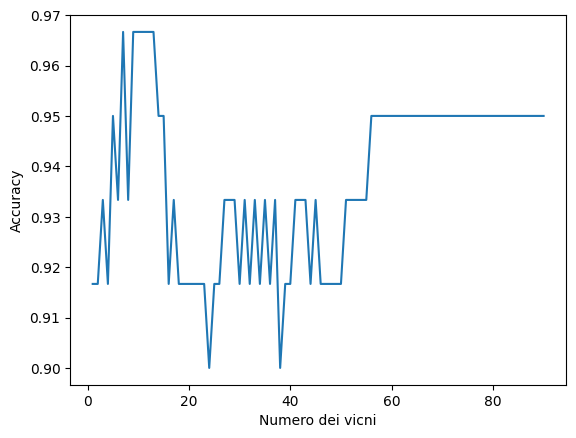

In [9]:
import numpy as np
from numpy import zeros
from sklearn import neighbors
from sklearn.datasets import load_iris
iris = load_iris()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)

best_accuracy=0
best_k=1
A=np.zeros(len(y_train), dtype=np.float64) # for storing accuracies
for n_neighbors in np.arange(1,len(y_train)+1):
    clf_knn3 = neighbors.KNeighborsClassifier(n_neighbors, weights='distance')
    # (n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=1, **kwargs)
    clf_knn3.fit(X_train, y_train)
    index=n_neighbors-1
    A[index]=clf_knn3.score(X_test, y_test)
    if best_accuracy<clf_knn3.score(X_test, y_test):
        best_accuracy=clf_knn3.score(X_test, y_test)
        best_k=n_neighbors
    #print("k neighbors="+str(n_neighbors))
    #print("accuracy="+str(clf_knn3.score(X_test, y_test)))

print("\n")
print("best k="+str(best_k))
print("best accuracy="+str(best_accuracy))

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#plt.xticks(np.arange(1, len(y_train)+1, 8))
plt.yticks(np.arange(0.0,1.0,0.01))
plt.ylabel("Accuracy")
plt.xlabel("Numero dei vicni")
plt.plot(np.arange(1,len(y_train)+1),A)

plt.show()

weighting:uniform
best k=7
best accuracy=0.9666666666666667

weighting:distance
best k=7
best accuracy=0.9666666666666667



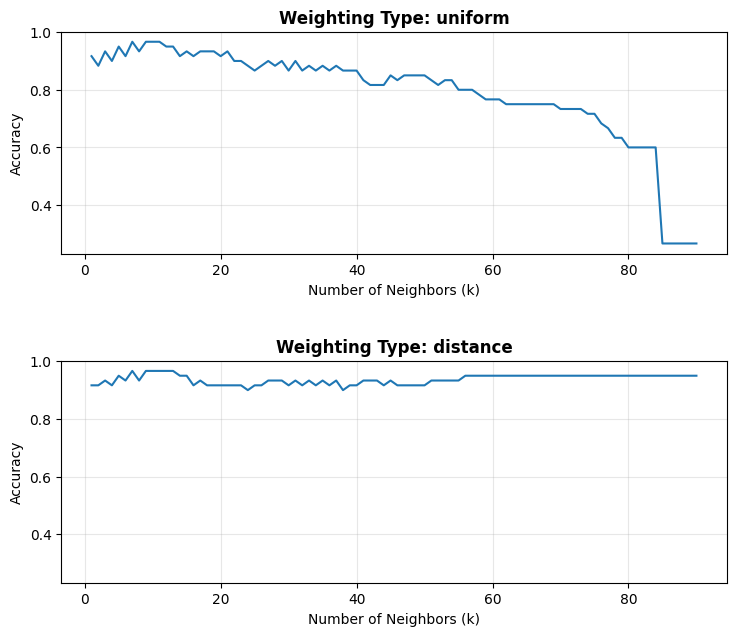

In [16]:
import numpy as np
from sklearn import neighbors
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)

# Impostiamo figsize per dare più altezza alla figura
f, (ax1, ax2) = plt.subplots(2, 1, sharey=True, figsize=(8, 7))

k_range = np.arange(1, len(y_train) + 1)
axes = [ax1, ax2]

for i, weight_type in enumerate(['uniform', 'distance']):
    print(f"weighting:{weight_type}")
    A = np.zeros(len(y_train), dtype=np.float64)
    best_accuracy = 0
    best_k = 1

    for n_neighbors in k_range:
        clf_knn2 = neighbors.KNeighborsClassifier(n_neighbors, weights=weight_type)
        clf_knn2.fit(X_train, y_train)
        index = n_neighbors - 1
        A[index] = clf_knn2.score(X_test, y_test)
        if best_accuracy < A[index]:
            best_accuracy = A[index]
            best_k = n_neighbors

    print(f"best k={best_k}")
    print(f"best accuracy={best_accuracy}\n")

    # Configurazione del subplot corrente
    ax = axes[i]
    ax.plot(k_range, A)
    ax.set_title(f'Weighting Type: {weight_type}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Neighbors (k)')
    ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.3)

# Distanzia verticalmente i due riquadri in modo pulito
plt.tight_layout(pad=3.0)

plt.show()

In the following cell we plot (overlapping) in the same picture both the diagrams on accuracy with the two kinds of weighting
of the vote of the neighbours (uniform and with distance)

###Plot the Iris dataset, in 2-D, with a red color for Setosa, blu for Versicolor, Green for Virginica. Choose in a way decided by you, the best subset of 2 features to plot the Iris data so that the classes are separated the most.

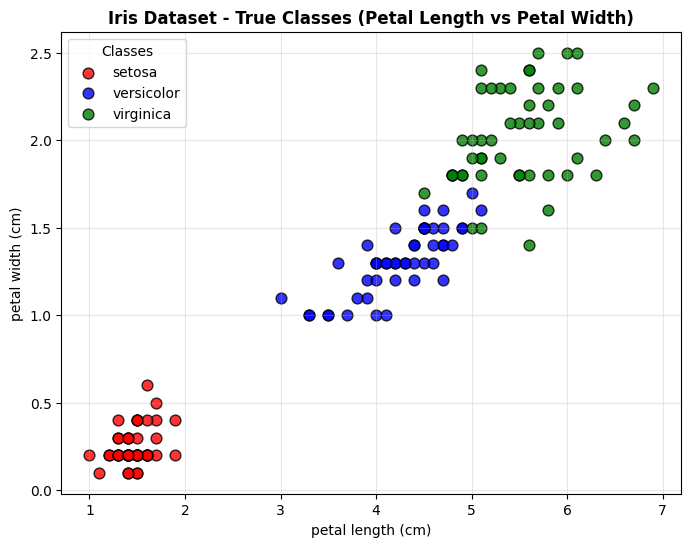

In [21]:
# Caricamento del dataset
iris = load_iris()
X = iris.data
y = iris.target

# Indici delle feature scelte: 2 (Petal Length) e 3 (Petal Width)
f1, f2 = 2, 3
feature_names = iris.feature_names
target_names = iris.target_names

# Mappatura dei colori richiesta dalla traccia
colors = {0: 'red', 1: 'blue', 2: 'green'}

# Creazione del grafico
plt.figure(figsize=(8, 6))
for cls in range(3):
    plt.scatter(X[y == cls, f1], X[y == cls, f2],
                color=colors[cls], label=target_names[cls],
                edgecolor='k', s=60, alpha=0.8)

# Personalizzazione
plt.title('Iris Dataset - True Classes (Petal Length vs Petal Width)', fontweight='bold')
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.legend(title="Classes")
plt.grid(alpha=0.3)
plt.show()

###Plot the Iris dataset, in 2-D, with the color as above determined by the k-nn estimation


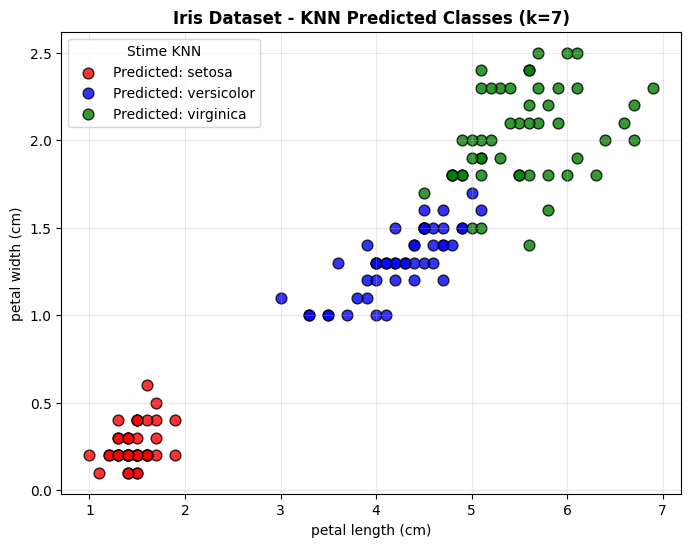

In [22]:


from sklearn.neighbors import KNeighborsClassifier

# Addestriamo il modello KNN con i parametri ottimali
best_k = 7
clf_knn_pred = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
# Per visualizzare la mappa globale, fittiamo e prediciamo sull'intero dataset X
clf_knn_pred.fit(X, y)
y_pred = clf_knn_pred.predict(X)

# Creazione del grafico basato sulle stime del KNN
plt.figure(figsize=(8, 6))
for cls in range(3):
    # Usiamo y_pred invece di y per determinare il colore di classificazione
    plt.scatter(X[y_pred == cls, f1], X[y_pred == cls, f2],
                color=colors[cls], label=f"Predicted: {target_names[cls]}",
                edgecolor='k', s=60, alpha=0.8)

# Personalizzazione
plt.title(f'Iris Dataset - KNN Predicted Classes (k={best_k})', fontweight='bold')
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.legend(title="Stime KNN")
plt.grid(alpha=0.3)
plt.show()

###In the following, extend the above exercize on k-nn using metric learning.
Use a kernel function for the distances computation.
Use $K(x_t, x_n) = exp(-\gamma ||x_t-x_n||^2)$ were $\gamma$ is the inverse of the variance. Its best value is the purpose of this cell, and it will be determined by you according to the accuracy on Iris. If you want to convert a Gaussian kernel into a distance you can use one of these formulas below:

1.   $d(x_t,x_n)=\sqrt{-\frac{1}{\gamma}*ln(K(x_t,x_n))}$

2.   $d(x_t,x_n)=\sqrt{K(x_t,x_t)-2*K(x_t,x_n)+K(x_n,x_n)}$


In [23]:
# Dividiamo i dati come fatto in precedenza
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)

# 1. Calcolo di gamma: l'inverso della varianza globale del set di addestramento
gamma_val = 1.0 / np.var(X_train)
print(f"Valore ottimale di gamma calcolato (inverso della varianza): {gamma_val:.4f}\n")

# 2. Definizione della funzione di distanza personalizzata tramite Kernel Gaussiano
def gaussian_kernel_distance(x1, x2, gamma=gamma_val):
    # Calcolo della distanza euclidea al quadrato tra i due vettori
    sq_dist = np.sum((x1 - x2) ** 2)
    # Valutazione del Kernel Gaussiano K(x1, x2)
    k_val = np.exp(-gamma * sq_dist)

    # Applicazione della Formula 2 semplificata: sqrt(2 - 2 * K(x1, x2))
    # np.maximum assicura che argomenti negativi vicini allo zero per arrotondamenti non blocchino la radice
    distance = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * k_val))
    return distance

# 3. Addestramento e Valutazione del modello K-NN con la nuova metrica
best_k = 7 # Manteniamo il best k trovato al passo precedente

# Inizializzazione del classificatore indicando la funzione custom nel parametro metric
clf_kernel = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric=gaussian_kernel_distance)

# Addestramento
clf_kernel.fit(X_train, y_train)

# Valutazione dell'accuratezza sul test set
accuracy = clf_kernel.score(X_test, y_test)

print(f"K-NN (k={best_k}) con distanza Kernel Gaussiano")
print("-" * 45)
print(f"Accuratezza raggiunta sul Test Set: {accuracy:.4f}")

Valore ottimale di gamma calcolato (inverso della varianza): 0.2470

K-NN (k=7) con distanza Kernel Gaussiano
---------------------------------------------
Accuratezza raggiunta sul Test Set: 0.9667


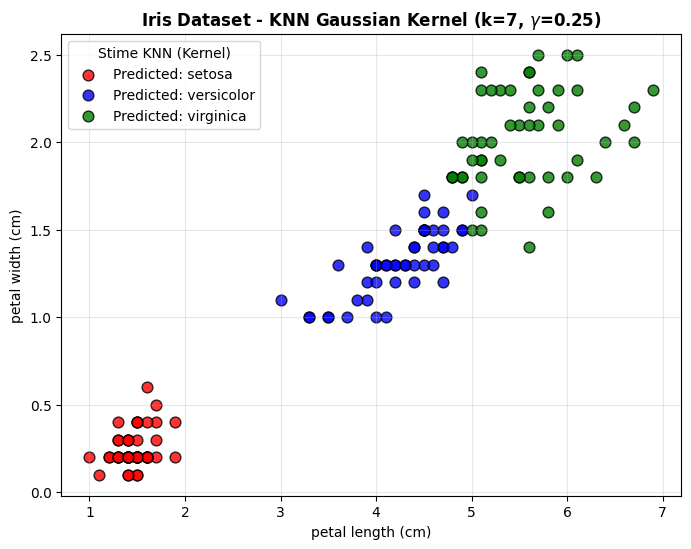

In [25]:
# Generiamo le predizioni per l'intero dataset usando il modello con Kernel Gaussiano
y_pred_kernel = clf_kernel.predict(X)

# Creazione del grafico
plt.figure(figsize=(8, 6))
for cls in range(3):
    plt.scatter(X[y_pred_kernel == cls, f1], X[y_pred_kernel == cls, f2],
                color=colors[cls], label=f"Predicted: {target_names[cls]}",
                edgecolor='k', s=60, alpha=0.8)

# Personalizzazione
plt.title(rf'Iris Dataset - KNN Gaussian Kernel (k={best_k}, $\gamma$={gamma_val:.2f})', fontweight='bold')
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.legend(title="Stime KNN (Kernel)")
plt.grid(alpha=0.3)
plt.show()